In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from plyfile import PlyData
import open3d as o3d
import torch
from torch.utils.data import Dataset, DataLoader
import os
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
PLY_PATH = os.path.join(os.getcwd(), "..", "data", "processed", "WatCahi_labeled.ply")

In [3]:
pcd = PlyData.read(PLY_PATH)

In [4]:
def load_heritage_ply(file_path):
    print(f"Loading {file_path} ...")
    plydata = PlyData.read(file_path)
    vertex_data = plydata['vertex'].data
    
    coords = np.vstack((vertex_data['x'], vertex_data['y'], vertex_data['z'])).T
    
    colors = np.vstack((vertex_data['red'], vertex_data['green'], vertex_data['blue'])).T / 255.0
    
    geom_features = np.vstack((
        vertex_data['scalar_Roughness_(0.05)'],
        vertex_data['scalar_Mean_curvature_(0.05)'],
        vertex_data['scalar_Normal_change_rate_(0.05)'],
        vertex_data['scalar_Anisotropy_(0.05)'],
        vertex_data['scalar_Planarity_(0.05)'],
        vertex_data['scalar_Linearity_(0.05)'],
        vertex_data['scalar_Surface_variation_(0.05)']
    )).T
    
    X = np.hstack((coords, colors, geom_features))
    
    labels_matrix = np.vstack((
        vertex_data['scalar_Intact_Brick'],      # Class 0
        vertex_data['scalar_Material_Spalling'], # Class 1
        vertex_data['scalar_Moderate_Crack'],    # Class 2
        vertex_data['scalar_Severe_Crack']       # Class 3
    )).T
    
    Y = np.argmax(labels_matrix, axis=1)
    
    print(f"Data Loaded Successfully!")
    print(f"Feature Matrix (X) shape: {X.shape}") # (3576852, 13)
    print(f"Label Vector (Y) shape: {Y.shape}")   # (3576852,)
    
    return X, Y

In [5]:
X,Y = load_heritage_ply(PLY_PATH)

Loading c:\Users\babxk\Documents\GitHub\archaeological-site\notebook\..\data\processed\WatCahi_labeled.ply ...
Data Loaded Successfully!
Feature Matrix (X) shape: (3576852, 13)
Label Vector (Y) shape: (3576852,)


In [ ]:
def radial_train_test_split(X, Y, test_size=0.2,start_angle_offset=90):

    
    coords_xy = X[:, 0:2]
    
    centroid_x, centroid_y = np.median(coords_xy, axis=0)
    print(f"Pagoda Centroid estimated at: X={centroid_x:.2f}, Y={centroid_y:.2f}")
    
    # Radian ในช่วง [-pi, pi]
    angles_rad = np.arctan2(coords_xy[:, 1] - centroid_y, coords_xy[:, 0] - centroid_x)
    
    angles_deg = np.degrees(angles_rad)
    angles_deg = np.mod(angles_deg + 360 + start_angle_offset, 360) 
    
    test_angle_span = 360 * test_size
    test_mask = angles_deg <= test_angle_span
    train_mask = ~test_mask
    
    X_train, Y_train = X[train_mask], Y[train_mask]
    X_test, Y_test = X[test_mask], Y[test_mask]
    
    print(f"Train Set: {len(Y_train)} points ({len(Y_train)/len(Y)*100:.1f}%)")
    print(f"Test Set: {len(Y_test)} points ({len(Y_test)/len(Y)*100:.1f}%)")
    
    print("\nClass Distribution Train:")
    unique, counts = np.unique(Y_train, return_counts=True)
    print(dict(zip(unique, counts)))
    
    print("Class Distribution Test:")
    unique, counts = np.unique(Y_test, return_counts=True)
    print(dict(zip(unique, counts)))
    
    return X_train, X_test, Y_train, Y_test

In [7]:
X_train, X_test, Y_train, Y_test = radial_train_test_split(X, Y, test_size=0.2)

Performing Radial (Angular) Split for Pagoda...
Pagoda Centroid estimated at: X=5.13, Y=0.14
Train Set: 2684069 points (75.0%)
Test Set: 892783 points (25.0%)

Class Distribution Train:
{np.int64(0): np.int64(114039), np.int64(1): np.int64(2570030)}
Class Distribution Test:
{np.int64(0): np.int64(24000), np.int64(1): np.int64(868783)}


In [ ]:
class HeritagePointCloudDataset(Dataset):
    def __init__(self, X_features, Y_labels, block_size=1.0, num_points=4096, min_points_per_block=1024):
     
        self.block_size = block_size
        self.num_points = num_points
        self.min_points_per_block = min_points_per_block
        
        # Standardize Geometric Features
        print("Standardizing Geometric Features...")
        self.scaler = StandardScaler()
        self.X_processed = X_features.copy() 
        self.X_processed[:, 6:13] = self.scaler.fit_transform(self.X_processed[:, 6:13])
        
        # หั่น Block
        print("Partitioning Point Cloud into Blocks...")
        self.blocks_data = self._partition_into_blocks(self.X_processed, Y_labels)
        print(f"Total valid blocks ready for training: {len(self.blocks_data)}")

    def _partition_into_blocks(self, X, Y):
        coords = X[:, 0:2] 
        coord_min = np.min(coords, axis=0)
        
        grid_indices = np.floor((coords - coord_min) / self.block_size).astype(int)
        
        # สร้าง Unique ID สำหรับแต่ละ Block
        grid_keys = np.array([f"{gx}_{gy}" for gx, gy in grid_indices])
        unique_keys = np.unique(grid_keys)
        
        blocks = []
        for key in unique_keys:
            point_idx = np.where(grid_keys == key)[0]
            
            if len(point_idx) < self.min_points_per_block:
                continue
                
            blocks.append({
                'X': X[point_idx, :],
                'Y': Y[point_idx]
            })
            
        return blocks

    def __len__(self):
        return len(self.blocks_data)

    def __getitem__(self, idx):
        block = self.blocks_data[idx]
        block_X = block['X']
        block_Y = block['Y']
        
        num_points_in_block = block_X.shape[0]
        
        if num_points_in_block >= self.num_points:
            selected_idx = np.random.choice(num_points_in_block, self.num_points, replace=False)
        else:
            selected_idx = np.random.choice(num_points_in_block, self.num_points, replace=True)
            
        sampled_X = block_X[selected_idx, :]
        sampled_Y = block_Y[selected_idx]
        
        # --- Zero-Centering ---
        xyz = sampled_X[:, 0:3]
        centroid = np.mean(xyz, axis=0) 
        sampled_X[:, 0:3] = xyz - centroid # Centroid อยู่ที่ (0,0,0)
        
        # Output shape: tensor_X -> [13, 8192], tensor_Y -> [8192]
        tensor_X = torch.tensor(sampled_X, dtype=torch.float32).transpose(0, 1)
        tensor_Y = torch.tensor(sampled_Y, dtype=torch.long)                    
        
        return tensor_X, tensor_Y

In [9]:
train_dataset = HeritagePointCloudDataset(X_train, Y_train, block_size=1.0)
test_dataset = HeritagePointCloudDataset(X_test, Y_test, block_size=1.0)

Standardizing Geometric Features...
Partitioning Point Cloud into Blocks...
Total valid blocks ready for training: 54
Standardizing Geometric Features...
Partitioning Point Cloud into Blocks...
Total valid blocks ready for training: 19


In [10]:
def create_dataloaders(X_train, Y_train, X_test, Y_test, batch_size=4):
    
    train_dataset = HeritagePointCloudDataset(
        X_features=X_train, 
        Y_labels=Y_train, 
        block_size=1.0, 
        num_points=8192, 
        min_points_per_block=1024
    )
    
    test_dataset = HeritagePointCloudDataset(
        X_features=X_test, 
        Y_labels=Y_test, 
        block_size=1.0, 
        num_points=8192, 
        min_points_per_block=1024
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    return train_loader, test_loader

In [11]:
train_loader, test_loader = create_dataloaders(X_train, Y_train, X_test, Y_test, batch_size=8)

Standardizing Geometric Features...
Partitioning Point Cloud into Blocks...
Total valid blocks ready for training: 54
Standardizing Geometric Features...
Partitioning Point Cloud into Blocks...
Total valid blocks ready for training: 19


In [12]:
def calculate_class_weights(Y_train, num_classes=4):
    unique, counts = np.unique(Y_train, return_counts=True)
    total_points = len(Y_train)
    
    weights = np.zeros(num_classes, dtype=np.float32)
    for cls, count in zip(unique, counts):
        weights[cls] = total_points / (num_classes * count)
    
    print(f"Class Weights: {weights}")
    return torch.tensor(weights, dtype=torch.float32)

In [13]:
class_weights = calculate_class_weights(Y_train)

Class Weights: [5.8841033  0.26109317 0.         0.        ]


In [14]:
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.cuda())

In [ ]:
class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        return focal_loss.mean()

In [ ]:
def knn(x, k):
    # x shape: [B, 3, N]
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x ** 2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    idx = pairwise_distance.topk(k=k, dim=-1)[1]   # [B, N, K]
    return idx

In [ ]:
def gather_neighbors(features, knn_idx):
    """
    features: [B, N, C]
    knn_idx: [B, N, K]
    """
    B, N, K = knn_idx.shape
    C = features.shape[-1]
    
    flat_features = features.reshape(B * N, C) # [B*N, C]
    
    batch_offsets = torch.arange(B, device=features.device).view(-1, 1, 1) * N
    flat_idx = (knn_idx + batch_offsets).view(-1) # [B*N*K]
    
    gathered_features = flat_features[flat_idx] # [B*N*K, C]
    
    return gathered_features.view(B, N, K, C)

In [ ]:
class LocalSpatialEncoding(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels + 10, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, xyz, features, knn_idx):
        B, C, N = features.size()
        K = knn_idx.size(-1)
        
        # [B, N, 3] และ [B, N, C]
        xyz_transposed = xyz.transpose(1, 2).contiguous() 
        feat_transposed = features.transpose(1, 2).contiguous()
        
        xyz_neighbors = gather_neighbors(xyz_transposed, knn_idx) # [B, N, K, 3]
        feat_neighbors = gather_neighbors(feat_transposed, knn_idx) # [B, N, K, C]
        
        xyz_center = xyz_transposed.unsqueeze(2).expand(-1, -1, K, -1) # [B, N, K, 3]
        relative_xyz = xyz_center - xyz_neighbors
        distance = torch.norm(relative_xyz, dim=-1, keepdim=True)
        
        loc_features = torch.cat([xyz_center, xyz_neighbors, relative_xyz, distance], dim=-1) # [B, N, K, 10]
        loc_features = loc_features.permute(0, 3, 1, 2) # [B, 10, N, K]
        
        feat_neighbors = feat_neighbors.permute(0, 3, 1, 2) # [B, C, N, K]
        concat_features = torch.cat([loc_features, feat_neighbors], dim=1) # [B, C+10, N, K]
        
        return self.mlp(concat_features)

In [ ]:
class AttentivePooling(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.score_fn = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(in_channels, 1, 1, bias=False)
        )

    def forward(self, x):
        scores = self.score_fn(x) # [B, 1, N, K]
        scores = F.softmax(scores, dim=-1) 
        features = torch.sum(x * scores, dim=-1) # [B, C, N]
        return features

In [ ]:
class RandLANet_Base(nn.Module):
    def __init__(self, num_classes=4, in_channels=13, k_neighbors=16):
        super().__init__()
        self.k = k_neighbors
        
        self.fc_start = nn.Sequential(
            nn.Conv1d(in_channels, 32, 1, bias=False),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Layer 1
        self.locse1 = LocalSpatialEncoding(32, 64)
        self.pool1 = AttentivePooling(64)
        
        # Layer 2
        self.locse2 = LocalSpatialEncoding(64, 128)
        self.pool2 = AttentivePooling(128)
        
        # Layer 3
        self.locse3 = LocalSpatialEncoding(128, 256)
        self.pool3 = AttentivePooling(256)
        
        # Classifier Head 
        self.fc_end = nn.Sequential(
            nn.Conv1d(64 + 128 + 256, 256, 1, bias=False),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3), 
            nn.Conv1d(256, 64, 1, bias=False),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(64, num_classes, 1)
        )

    def forward(self, x):
        # แยก XYZ ออกมาเพื่อคำนวณระยะทาง
        xyz = x[:, 0:3, :].contiguous()
        
        features = self.fc_start(x)
        
        # หาเพื่อนบ้านที่ใกล้ที่สุด 16 จุด
        knn_idx = knn(xyz, self.k)
        
        f1 = self.pool1(self.locse1(xyz, features, knn_idx)) # [B, 64, N]
        f2 = self.pool2(self.locse2(xyz, f1, knn_idx))       # [B, 128, N]
        f3 = self.pool3(self.locse3(xyz, f2, knn_idx))       # [B, 256, N]
        
        concat_features = torch.cat([f1, f2, f3], dim=1)     # [B, 448, N]
        logits = self.fc_end(concat_features)                # [B, 4, N]
        
        return logits

In [21]:
model = RandLANet_Base(num_classes=4, in_channels=13, k_neighbors=16).cuda()

In [22]:
def train_max_acc_fast(model, train_loader, num_epochs=100, class_weights=None):
    model = model.cuda()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    criterion = FocalLoss(alpha=class_weights.cuda(), gamma=2.0)

    scaler = GradScaler() 
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.cuda(), targets.cuda()
            optimizer.zero_grad()
            
            
            with autocast():
                logits = model(inputs) 
                loss = criterion(logits, targets) 
            
           
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            
           
            if batch_idx % 10 == 0:
                print(f"Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")

In [23]:
train_max_acc_fast(model, train_loader, num_epochs=20, class_weights=class_weights)

C:\Users\babxk\AppData\Local\Temp\ipykernel_984\3000919803.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
C:\Users\babxk\AppData\Local\Temp\ipykernel_984\3000919803.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Batch [0/6] Loss: 0.4413
Batch [0/6] Loss: 0.0751
Batch [0/6] Loss: 0.1568
Batch [0/6] Loss: 0.1969
Batch [0/6] Loss: 0.0894
Batch [0/6] Loss: 0.1183
Batch [0/6] Loss: 0.1049
Batch [0/6] Loss: 0.0545
Batch [0/6] Loss: 0.0537
Batch [0/6] Loss: 0.0472
Batch [0/6] Loss: 0.0459
Batch [0/6] Loss: 0.1301
Batch [0/6] Loss: 0.0493
Batch [0/6] Loss: 0.0904
Batch [0/6] Loss: 0.0632
Batch [0/6] Loss: 0.0675
Batch [0/6] Loss: 0.0634
Batch [0/6] Loss: 0.0336
Batch [0/6] Loss: 0.0634
Batch [0/6] Loss: 0.0447


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
def evaluate_model(model, test_loader, num_classes=4):
    model.eval() 
    
    all_preds = []
    all_targets = []
    
    class_names = ['0_Intact_Brick', '1_Material_Spalling', '2_Moderate_Crack', '3_Severe_Crack']
    
    with torch.no_grad(): 
        for inputs, targets in test_loader:
            inputs = inputs.cuda()
            targets = targets.cuda()
            
            logits = model(inputs)            # [Batch, 4, Points]
            preds = torch.argmax(logits, dim=1) # [Batch, Points]
            
            all_preds.append(preds.cpu().numpy().flatten())
            all_targets.append(targets.cpu().numpy().flatten())
            
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    
    print("\n" + "="*50)
    print(" Classification Report ")
    print("="*50)
    print(classification_report(all_targets, all_preds, labels=[0, 1, 2, 3], target_names=class_names, digits=4, zero_division=0))
    
    print("\n" + "="*50)
    print(" Intersection over Union (IoU)")
    print("="*50)
    ious = []
    for c in range(num_classes):
        intersection = np.sum((all_preds == c) & (all_targets == c))
        union = np.sum((all_preds == c) | (all_targets == c))
        iou = intersection / union if union > 0 else np.nan
        ious.append(iou)
        print(f"[{class_names[c]}] IoU: {iou*100:.2f}%")
        
    print("-" * 30)
    print(f"Mean IoU (mIoU): {np.nanmean(ious)*100:.2f}%\n")
    
    cm = confusion_matrix(all_targets, all_preds)
    
    return cm, class_names

In [26]:
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(10, 8))
    
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('Confusion Matrix (%)', fontsize=16, pad=20)
    plt.ylabel('Actual Label (ของจริง)', fontsize=12)
    plt.xlabel('Predicted Label (โมเดลทาย)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [27]:
def visualize_prediction_3d(model, test_loader, num_points=4096):

    model.eval()
    inputs, targets = next(iter(test_loader)) # ดึงมาแค่ 1 Batch แรก
    
    with torch.no_grad():
        logits = model(inputs.cuda())
        preds = torch.argmax(logits, dim=1).cpu()
    
    block_idx = 0
    xyz = inputs[block_idx, 0:3, :].numpy() # [3, N] -> แกน X, Y, Z
    true_labels = targets[block_idx].numpy()
    pred_labels = preds[block_idx].numpy()
    
    fig = plt.figure(figsize=(16, 7))
    
    # 0: เทา(ปกติ), 1: ส้ม(Spalling), 2: แดงอ่อน(Moderate), 3: แดงเข้ม(Severe)
    colors = {0: '#B0BEC5', 1: '#FFB74D', 2: '#E57373', 3: '#B71C1C'}
    true_c = [colors[l] for l in true_labels]
    pred_c = [colors[l] for l in pred_labels]
    
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(xyz[0], xyz[1], xyz[2], c=true_c, s=5, alpha=0.8)
    ax1.set_title("Ground Truth", fontsize=14)
    ax1.axis('off') 
    
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(xyz[0], xyz[1], xyz[2], c=pred_c, s=5, alpha=0.8)
    ax2.set_title("Model Prediction", fontsize=14)
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

In [28]:
cm, classes = evaluate_model(model, test_loader)


 Classification Report 
                     precision    recall  f1-score   support

     0_Intact_Brick     0.0286    0.9951    0.0557      2471
1_Material_Spalling     0.9998    0.4554    0.6258    153177
   2_Moderate_Crack     0.0000    0.0000    0.0000         0
     3_Severe_Crack     0.0000    0.0000    0.0000         0

           accuracy                         0.4640    155648
          macro avg     0.2571    0.3626    0.1704    155648
       weighted avg     0.9844    0.4640    0.6167    155648


 Intersection over Union (IoU)
[0_Intact_Brick] IoU: 2.86%
[1_Material_Spalling] IoU: 45.54%
[2_Moderate_Crack] IoU: nan%
[3_Severe_Crack] IoU: nan%
------------------------------
Mean IoU (mIoU): 24.20%



C:\Users\babxk\AppData\Local\Temp\ipykernel_984\671559113.py:13: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\babxk\AppData\Local\Temp\ipykernel_984\671559113.py:13: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\babxk\AppData\Local\Temp\ipykernel_984\671559113.py:13: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\babxk\AppData\Local\Temp\ipykernel_984\671559113.py:13: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\babxk\AppData\Local\Temp\ipykernel_984\671559113.py:13: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\babxk\AppData\Local\Temp\ipykernel_984\671559113.py:13: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s

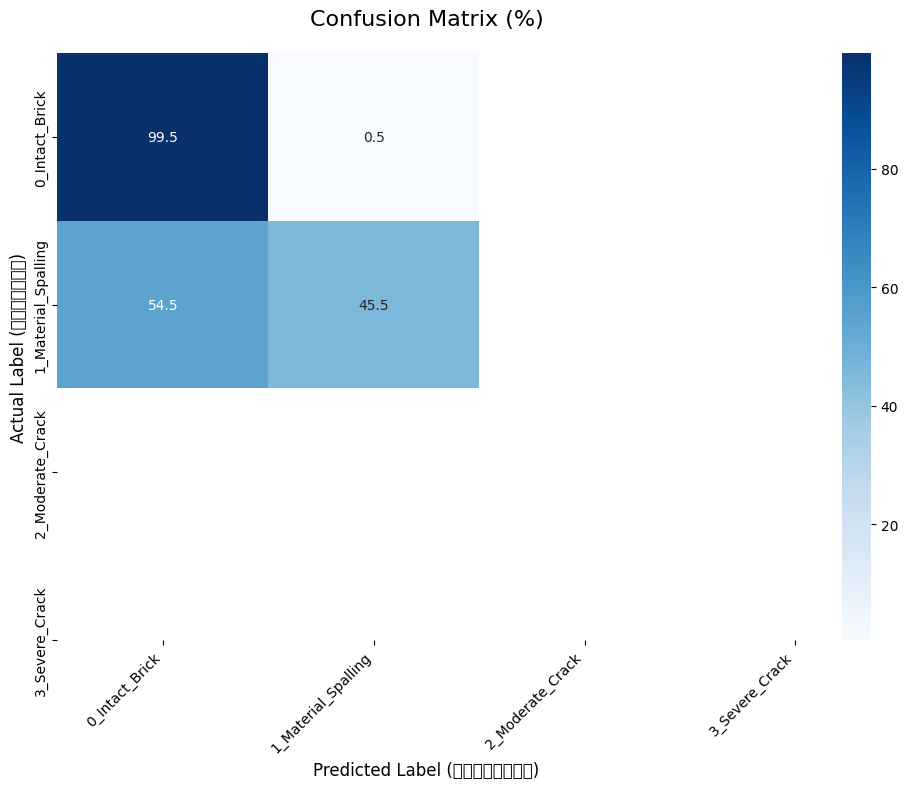

In [29]:
plot_confusion_matrix(cm, classes)

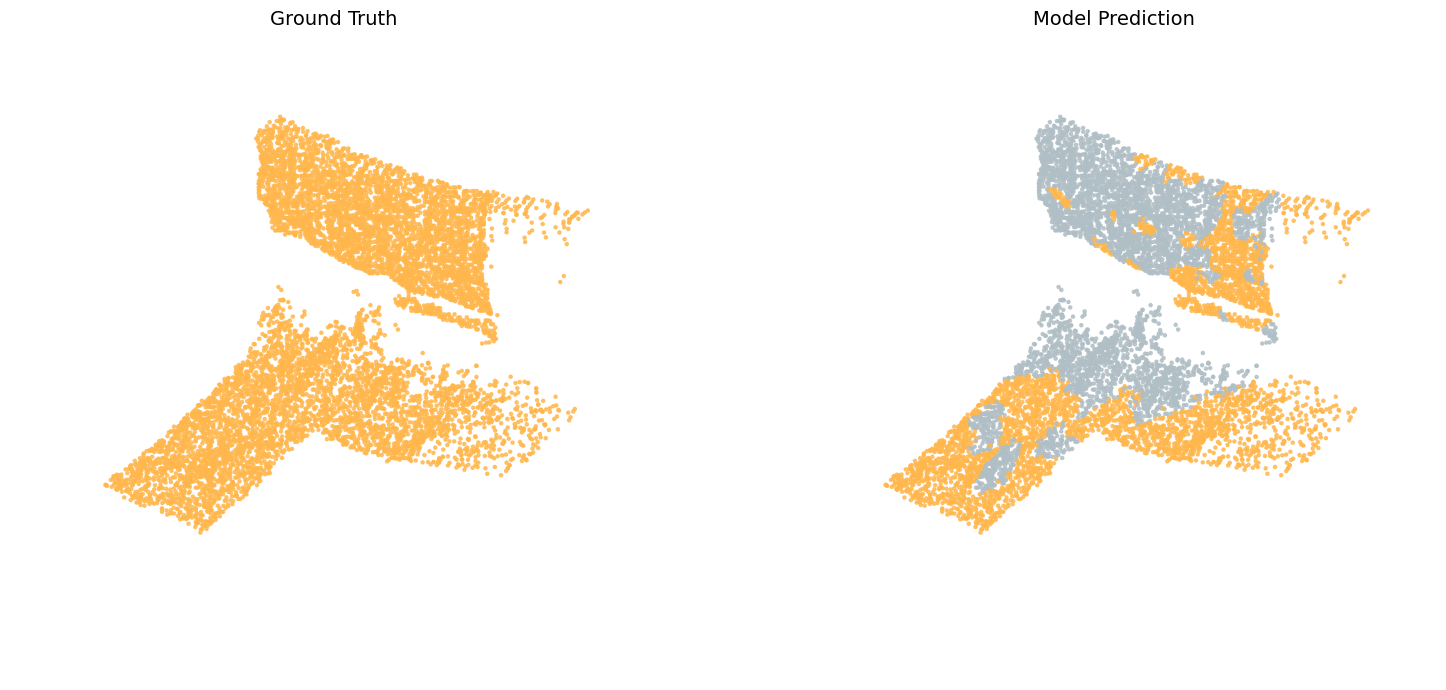

In [30]:
visualize_prediction_3d(model, test_loader)